Loading demand profiles...
Demand profiles loaded!
Loading production data...
Production profiles loaded!


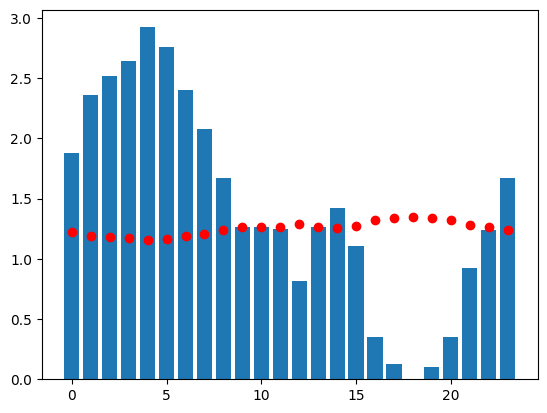

: 

In [ ]:
from datamanager import DataManager
import numpy as np
import matplotlib.pyplot as plt

agents = ["H1", "H2", "H3", "H4", "H5"]
caps = {"H1": 1, "H2": 1, "H3": 0, "H4": 3, "H5": 1}
var = 1

dm = DataManager()
price_array = dm.get_price_array()

def capacity_plot(start, agents, caps, var):

    def compute_daily_demand(step, agents):
        total_daily_demand = 0
        max_hourly_production = 0
        max_hourly_demand = 0
        for aid in agents:
            total_daily_demand += dm.get_agent_summed_demand(aid)
            agent_production = dm.get_agent_maxproduction(aid)*caps[aid]
            max_hourly_production += agent_production
        max_hourly_demand = dm.get_max_hourly_demand(agents)
        return total_daily_demand

    def compute_residual_demand(step):
        # Gets the total demand and supply for the next 24 hours
        total_prod = 0
        for aid in agents:
            base_prod = dm.get_agent_daily_prod(aid, step)
            total_prod += base_prod*caps[aid]
        # Compute the residual demand
        residual_demand = compute_daily_demand(step, agents) - total_prod
        residual_demand = max(residual_demand, 0)
        return residual_demand

    def compute_capacity_limitation(step, var):
        daily_prices = price_array[step:step+24]
        # Hack for out of bounds index
        if len(daily_prices) < 24:
            daily_prices = price_array[0:24]
        max_price = np.max(daily_prices)
        min_price = np.min(daily_prices)
        mid_price = (max_price + min_price)/2
        avg_cap = compute_residual_demand(step)/24
        capacity_limitation = avg_cap - var * avg_cap * 2 * (daily_prices - mid_price) / (max_price - min_price)
        return capacity_limitation, daily_prices

    cap_limits, daily_prices = compute_capacity_limitation(start, var)
    plt.bar(range(len(cap_limits)), cap_limits)
    plt.scatter(range(len(daily_prices)), daily_prices, color='red')

    #print(len(cap_limits))
    

capacity_plot(24, agents, caps, var)


39.45238333333333
48.32527975543363


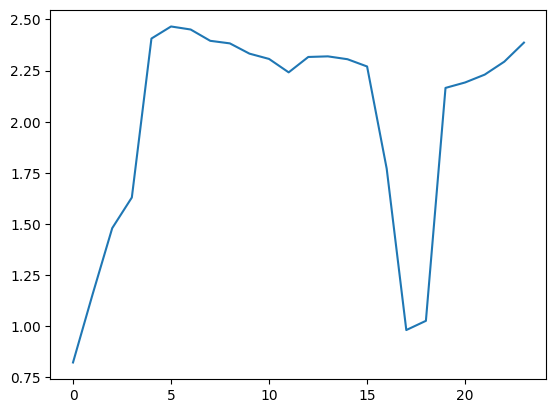

In [7]:
agents = ["H1", "H2", "H3", "H4", "H5"]
caps = {"H1": 3, "H2": 3, "H3": 0, "H4": 1, "H5": 2}
var = 0.5

capacity_plot(48, agents, caps, var)
